# Simulation électrostatique FEM — Électrodes coplanaires

Calcul de la distribution de potentiel électrique et du champ électrique dans un isolant avec une électrode coplanaire placée sur la face supérieure.

**Méthode :** Éléments finis  
**Géométrie :** Capteur capacitif avec électrodes coplanaires

## 1. Imports et configuration

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from matplotlib.tri import Triangulation
import matplotlib.patches as patches

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


## 2. Définition de la classe `CoplanarElectrodesFEM`

In [7]:
class CoplanarElectrodesFEM:
    """
    FEM pour electrostatique avec electrodes coplanaires sur la face superieure.
    Resout l'equation de Laplace : div(eps grad phi) = 0
    Domaine 3D : x in [0, length], y in [0, height], z in [0, depth]
    """

    def __init__(self, use_electrode2=True, length=1.0, height=0.5, depth=0.3,
                 nx=20, ny=20, nz=15, electrode1_pos=(0.4, 0.6,0.14,0.16),
                 electrode2_pos=(0.7,0.8,0.1,0.2), epsilon_r=4.0):
        self.use_electrode2  = use_electrode2
        self.length          = length
        self.height          = height
        self.depth           = depth
        self.nx              = nx
        self.ny              = ny
        self.nz              = nz
        self.electrode1_pos  = electrode1_pos
        self.electrode2_pos  = electrode2_pos
        self.epsilon_r       = epsilon_r
        self.epsilon_0       = 8.854187817e-12  # F/m
        self.generate_mesh()

    # ------------------------------------------------------------------
    # Maillage
    # ------------------------------------------------------------------

    def generate_mesh(self):
        """Genere un maillage tetraedrique structure 3D (6 tets par hexaedre)."""
        x = np.linspace(0, self.length, self.nx)
        y = np.linspace(0, self.height, self.ny)
        z = np.linspace(0, self.depth,  self.nz)
        X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

        self.nodes   = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
        self.n_nodes = len(self.nodes)

        def node_id(i, j, k):
            return i * (self.ny * self.nz) + j * self.nz + k

        tets = []
        for i in range(self.nx - 1):
            for j in range(self.ny - 1):
                for k in range(self.nz - 1):
                    n000 = node_id(i,   j,   k  )
                    n100 = node_id(i+1, j,   k  )
                    n010 = node_id(i,   j+1, k  )
                    n110 = node_id(i+1, j+1, k  )
                    n001 = node_id(i,   j,   k+1)
                    n101 = node_id(i+1, j,   k+1)
                    n011 = node_id(i,   j+1, k+1)
                    n111 = node_id(i+1, j+1, k+1)
                    tets.append([n000, n100, n110, n111])
                    tets.append([n000, n110, n010, n111])
                    tets.append([n000, n010, n011, n111])
                    tets.append([n000, n011, n001, n111])
                    tets.append([n000, n001, n101, n111])
                    tets.append([n000, n101, n100, n111])

        self.elements   = np.array(tets)          # shape (N_elem, 4)
        self.n_elements = len(self.elements)

        # Face superieure y = height
        top_mask = np.abs(self.nodes[:, 1] - self.height) < 1e-10
        top_idx  = np.where(top_mask)[0]

        x1s, x1e, z1s, z1e = self.electrode1_pos[:4]   
        self.electrode1_nodes = top_idx[(self.nodes[top_idx, 0] >= x1s) & (self.nodes[top_idx, 0] <= x1e) & (self.nodes[top_idx, 2] >= z1s) & (self.nodes[top_idx, 2] <= z1e)]

        if self.use_electrode2:
            x2s, x2e, z2s, z2e = self.electrode2_pos

            self.electrode2_nodes = top_idx[
                (self.nodes[top_idx, 0] >= x2s) & (self.nodes[top_idx, 0] <= x2e) &
                (self.nodes[top_idx, 2] >= z2s) & (self.nodes[top_idx, 2] <= z2e)
            ]
        else:
            self.electrode2_nodes = np.array([])

        # Face inferieure y = 0
        self.bottom_nodes = np.where(np.abs(self.nodes[:, 1]) < 1e-10)[0]

        print(f"Maillage 3D  : {self.n_nodes} noeuds, {self.n_elements} tetraedres")
        print(f"Domaine      : {self.length} x {self.height} x {self.depth} m")
        print(f"Grille       : {self.nx} x {self.ny} x {self.nz} noeuds")
        print(f"elements.shape = {self.elements.shape}  (doit etre (N, 4))")
        print(f"Electrode 1  : {len(self.electrode1_nodes)} noeuds "
              f"(x in [{x1s:.2f}, {x1e:.2f}] m)")
        if self.use_electrode2 and self.electrode2_pos is not None:
            print(f"Electrode 2  : {len(self.electrode2_nodes)} noeuds "
                  f"(x in [{x2s:.2f}, {x2e:.2f}] m)")

    # ------------------------------------------------------------------
    # Assemblage FEM
    # ------------------------------------------------------------------

    def local_stiffness_matrix(self, elem_nodes):
        """Matrice de rigidite locale 4x4 pour un tetraedre lineaire P1."""
        # elem_nodes : array (4, 3)
        coords = np.array(elem_nodes)          # (4, 3)
        M = np.hstack([np.ones((4, 1)), coords])  # (4, 4)
        volume = abs(np.linalg.det(M)) / 6.0
        if volume < 1e-20:
            return np.zeros((4, 4))
        M_inv = np.linalg.inv(M)
        grads = M_inv[1:, :].T   # (3, 4) : grads[:, i] = grad N_i
        eps   = self.epsilon_0 * self.epsilon_r
        return eps * volume * (grads @ grads.T)  # (4, 4)

    def assemble_global_matrix(self):
        """Assemble la matrice de rigidite globale (sparse)."""
        K = lil_matrix((self.n_nodes, self.n_nodes))
        for elem in self.elements:              # elem : 4 indices
            K_loc = self.local_stiffness_matrix(self.nodes[elem])  # (4,4)
            for i in range(4):
                for j in range(4):
                    K[elem[i], elem[j]] += K_loc[i, j]
        return K.tocsr()

    # ------------------------------------------------------------------
    # Conditions aux limites & resolution
    # ------------------------------------------------------------------

    def apply_boundary_conditions(self, K, F,
                                   V_electrode1=100.0,
                                   V_electrode2=0.0,
                                   V_bottom=0.0):
        """Conditions de Dirichlet par substitution directe."""
        K_mod = K.tolil()
        F_mod = F.copy()

        def impose(node, val):
            K_mod[node, :] = 0
            K_mod[node, node] = 1
            F_mod[node] = val

        for node in self.electrode1_nodes:
            impose(node, V_electrode1)
        if self.use_electrode2:
            for node in self.electrode2_nodes:
                impose(node, V_electrode2)
        for node in self.bottom_nodes:
            impose(node, V_bottom)

        return K_mod.tocsr(), F_mod

    def solve(self, V_electrode1=100.0, V_electrode2=0.0, V_bottom=0.0):
        """Assemble et resout le systeme lineaire."""
        print("Assemblage de la matrice globale...")
        K = self.assemble_global_matrix()
        F = np.zeros(self.n_nodes)
        print("Application des conditions aux limites...")
        K_mod, F_mod = self.apply_boundary_conditions(
            K, F, V_electrode1, V_electrode2, V_bottom)
        print("Resolution du systeme lineaire...")
        self.phi = spsolve(K_mod, F_mod)
        print(f"phi in [{self.phi.min():.3f}, {self.phi.max():.3f}] V")
        return self.phi 
    # ------------------------------------------------------------------
    # Champ electrique
    # ------------------------------------------------------------------

    def compute_electric_field(self):
        """Calcule E = -grad(phi) par element (constante par tetraedre)."""
        E = np.zeros((self.n_elements, 3))
        for k, elem in enumerate(self.elements):
            coords = self.nodes[elem]                        # (4, 3)
            M      = np.hstack([np.ones((4, 1)), coords])   # (4, 4)
            try:
                M_inv = np.linalg.inv(M)
            except np.linalg.LinAlgError:
                continue
            grad_phi = M_inv[1:, :] @ self.phi[elem]        # (3,1)
            E[k]     = -grad_phi
        self.E_field = E
        Emag = np.linalg.norm(E, axis=1)
        print(f"|E| max = {Emag.max():.2f} V/m,  |E| moy = {Emag.mean():.2f} V/m")
        return E

    # ------------------------------------------------------------------
    # Visualisation
    # ------------------------------------------------------------------

    def plot_results(self, V_electrode1=100.0, V_electrode2=0.0,
                     V_bottom=0.0, x_cuts=None, z_cut=None):
        """Figures de resultats via coupes 2D dans le volume 3D."""
        if z_cut is None:
            z_cut = self.depth / 2.0

        z_mesh = np.unique(self.nodes[:, 2])
        z_snap = z_mesh[np.argmin(np.abs(z_mesh - z_cut))]
        tol_z  = self.depth / (2*(self.nz-1))

        cut_mask  = np.abs(self.nodes[:, 2] - z_snap) < tol_z
        cut_idx   = np.where(cut_mask)[0]
        local_id  = {g: l for l, g in enumerate(cut_idx)}
        cut_nodes = self.nodes[cut_idx]
        cut_phi   = self.phi[cut_idx]

        cut_tris = []
        for elem in self.elements:
            in_cut = [n for n in elem if n in local_id]
            if len(in_cut) == 3:
                cut_tris.append([local_id[n] for n in in_cut])
        cut_tris = np.array(cut_tris) if cut_tris else np.zeros((0, 3), dtype=int)
        tri = Triangulation(cut_nodes[:, 0], cut_nodes[:, 1], cut_tris)

        x1s, x1e,z1s, z1e = self.electrode1_pos
        levels = np.linspace(cut_phi.min(), cut_phi.max(), 25)

        # ── Figure 1 : maillage / potentiel / equipotentielles ──────
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f"Coupe z = {z_snap:.3f} m  "
                     f"(domaine {self.length} x {self.height} x {self.depth} m)",
                     fontsize=12, fontweight='bold')
        fig.subplots_adjust(left=0.06, right=0.97, top=0.85,
                            bottom=0.12, wspace=0.45)

        ax1 = axes[0]
        ax1.triplot(tri, 'k-', linewidth=0.2, alpha=0.3)
        ax1.add_patch(patches.Rectangle(
            (x1s, self.height - 0.01), x1e - x1s, 0.02,
            lw=2, edgecolor='red', facecolor='red', alpha=0.7,
            label=f'Electrode 1 ({V_electrode1} V)'))
        if self.use_electrode2 and self.electrode2_pos is not None:
            x2s, x2e, z2s, z2e = self.electrode2_pos
            ax1.add_patch(patches.Rectangle(
                (x2s, self.height - 0.01), x2e - x2s, 0.02,
                lw=2, edgecolor='blue', facecolor='blue', alpha=0.7,
                label=f'Electrode 2 ({V_electrode2} V)'))
        ax1.set(xlabel='x (m)', ylabel='y (m)')
        ax1.set_title('Maillage (coupe z)', fontsize=11, fontweight='bold')
        ax1.set_aspect('equal'); ax1.grid(True, alpha=0.2)
        ax1.legend(fontsize=8, loc='lower left')

        ax2 = axes[1]
        cf2 = ax2.tricontourf(tri, cut_phi, levels=levels, cmap='RdYlBu_r')
        cb2 = plt.colorbar(cf2, ax=ax2, fraction=0.046, pad=0.04)
        cb2.set_label('phi (V)', fontsize=9)
        ax2.set(xlabel='x (m)', ylabel='y (m)')
        ax2.set_title('Potentiel electrique', fontsize=11, fontweight='bold')
        ax2.set_aspect('equal')

        ax3 = axes[2]
        ax3.tricontourf(tri, cut_phi, levels=levels, cmap='RdYlBu_r', alpha=0.6)
        ax3.tricontour(tri, cut_phi, levels=20,
                       colors='black', linewidths=1, alpha=0.8)
        ax3.set(xlabel='x (m)', ylabel='y (m)')
        ax3.set_title('Lignes equipotentielles', fontsize=11, fontweight='bold')
        ax3.set_aspect('equal')

        plt.savefig('coplanar_3d_results.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Figure 1 sauvegardee : coplanar_3d_results.png")

        # ── Figure 2 : profils V(y) et V(x) ────────────────────────
        fig2, (ax_cut, ax_h) = plt.subplots(1, 2, figsize=(14, 5))
        fig2.suptitle(f"Profils de potentiel - coupe z = {z_snap:.3f} m",
                      fontsize=12, fontweight='bold')
        fig2.subplots_adjust(left=0.08, right=0.97, top=0.88,
                             bottom=0.13, wspace=0.35)

        if x_cuts is None:
            x_cuts_used = [round(self.length * f, 3)
                           for f in [0.1, 0.25, 0.5, 0.75, 0.99]]
        else:
            x_cuts_used = x_cuts

        tol_xy     = self.length / (2*(self.nx-1))
        x_mesh_cut = np.unique(cut_nodes[:, 0])
        colors_vy  = plt.cm.tab10(np.linspace(0, 0.9, len(x_cuts_used)))

        for xc, col in zip(x_cuts_used, colors_vy):
            if not (0 <= xc <= self.length):
                raise ValueError(f"x_cuts contient {xc} m hors du domaine.")
            xc_snap = x_mesh_cut[np.argmin(np.abs(x_mesh_cut - xc))]
            mask    = np.abs(cut_nodes[:, 0] - xc_snap) < tol_xy
            y_v, p_v = cut_nodes[mask, 1], cut_phi[mask]
            si = np.argsort(y_v)
            ax_cut.plot(y_v[si], p_v[si], '-o', color=col,
                        lw=2, ms=4, label=f'x = {xc_snap:.3f} m')

        ax_cut.axvline(self.height, ls='--', color='red',   alpha=0.6)
        ax_cut.axvline(0,           ls='--', color='black', alpha=0.6)
        ax_cut.set(xlabel='y (m)', ylabel='phi (V)', xlim=(0, self.height))
        ax_cut.set_title('Profils V(y)', fontsize=11, fontweight='bold')
        ax_cut.legend(fontsize=8); ax_cut.grid(True, alpha=0.3)

        for _, h in [(0.2, 0.2*self.height),
                     (0.5, 0.5*self.height),
                     (0.8, 0.8*self.height)]:
            tol_h = self.height / (2 * (self.ny - 1))
            mask_h = np.abs(cut_nodes[:, 1] - h) < tol_h
            x_h, p_h = cut_nodes[mask_h, 0], cut_phi[mask_h]
            si = np.argsort(x_h)
            ax_h.plot(x_h[si], p_h[si], '-o', lw=2, ms=3,
                      label=f'y = {h:.2f} m')

        ax_h.axvspan(x1s, x1e, alpha=0.2, color='red', label='Electrode 1')
        if self.use_electrode2 and self.electrode2_pos is not None:
            ax_h.axvspan(x2s, x2e, alpha=0.2, color='blue', label='Electrode 2')
        ax_h.set(xlabel='x (m)', ylabel='phi (V)', xlim=(0, self.length))
        ax_h.set_title('Profils V(x)', fontsize=11, fontweight='bold')
        ax_h.legend(fontsize=8); ax_h.grid(True, alpha=0.3)

        plt.savefig('coplanar_3d_profiles.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Figure 2 sauvegardee : coplanar_3d_profiles.png")

    # ------------------------------------------------------------------
    # Profil V(z) : potentiel le long de z pour differentes positions (x, y)
    # ------------------------------------------------------------------

    def plot_profile_z(self, xy_points=None, x_cut=None, y_cut=None):
        """
        Trace le profil 
        ) le long de l'axe z pour differents points (x, y).

        Parametres
        ----------
        xy_points : list of (x, y) tuples
            Points (x, y) pour lesquels tracer V(z).
            Par defaut : 3 positions representatives.
        x_cut : float, optional
            Si fourni avec y_cut, ajoute ce point unique.
        y_cut : float, optional
            Hauteur y pour le profil (ex: 0.25 = milieu du domaine).
        """
        if xy_points is None:
            xy_points = [
                (self.length * 0.25,  self.height * 0.7),   # proche electrode, haut
                (self.length * 0.75,  self.height * 0.5),   # centre du domaine
                (self.length * 0.5,  self.height * 0.25),   # pres du fond
            ]
        if x_cut is not None and y_cut is not None:
            xy_points = xy_points + [(x_cut, y_cut)]

        z_mesh = np.unique(self.nodes[:, 2])
        x_mesh = np.unique(self.nodes[:, 0])
        y_mesh = np.unique(self.nodes[:, 1])
        tol_x  = self.length / (2 * (self.nx - 1))
        tol_y  = self.height / (2 * (self.ny - 1))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Profil V(z) — variation du potentiel selon la profondeur z',
                     fontsize=12, fontweight='bold')
        fig.subplots_adjust(left=0.08, right=0.97, top=0.88,
                            bottom=0.13, wspace=0.35)

        colors = plt.cm.tab10(np.linspace(0, 0.9, len(xy_points)))

        for (xc, yc), col in zip(xy_points, colors):
            # Snap vers le noeud de maillage le plus proche
            xc_snap = x_mesh[np.argmin(np.abs(x_mesh - xc))]
            yc_snap = y_mesh[np.argmin(np.abs(y_mesh - yc))]

            mask = (np.abs(self.nodes[:, 0] - xc_snap) < tol_x) & \
                   (np.abs(self.nodes[:, 1] - yc_snap) < tol_y)

            z_vals  = self.nodes[mask, 2]
            phi_vals = self.phi[mask]
            si = np.argsort(z_vals)
            label = f'x={xc_snap:.2f} m, y={yc_snap:.2f} m'

            ax1.plot(z_vals[si], phi_vals[si], '-o', color=col,
                     lw=2, ms=4, label=label)
            ax2.plot(z_vals[si], phi_vals[si], '-o', color=col,
                     lw=2, ms=4, label=label)

        # Annotations geometriques
        ax1.axvline(0,          ls='--', color='gray',  alpha=0.6, label='z = 0')
        ax1.axvline(self.depth, ls='--', color='gray',  alpha=0.6, label=f'z = {self.depth} m')

        ax1.set(xlabel='z (m)', ylabel='phi (V)',
                xlim=(0, self.depth),
                title='V(z) — echelle lineaire')
        ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

        # Axe 2 : variation normalisee pour comparer les formes
        ax2.set(xlabel='z (m)', ylabel='phi (V)',
                xlim=(0, self.depth),
                title='V(z) — zoom sur la variation')
        # Afficher l'ecart max-min dans la legende
        for (xc, yc), col in zip(xy_points, colors):
            xc_snap = x_mesh[np.argmin(np.abs(x_mesh - xc))]
            yc_snap = y_mesh[np.argmin(np.abs(y_mesh - yc))]
            mask = (np.abs(self.nodes[:, 0] - xc_snap) < tol_x) & \
                   (np.abs(self.nodes[:, 1] - yc_snap) < tol_y)
            phi_vals = self.phi[mask]
            delta = phi_vals.max() - phi_vals.min()
            print(f'  x={xc_snap:.2f} m, y={yc_snap:.2f} m : '
                  f'V in [{phi_vals.min():.4f}, {phi_vals.max():.4f}] V  '
                  f'(Delta = {delta:.4f} V)')

        ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

        plt.savefig('coplanar_3d_profile_z.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Figure sauvegardee : coplanar_3d_profile_z.png')
        print()
        print('Interpretation : si V(z) est quasi-constant, le champ est')
        print('essentiellement 2D dans le plan (x,y) — la geometrie est')
        print('suffisamment large en z. Une variation notable indique un')
        print('effet de bord en profondeur.')


## 3. Paramètres de simulation

In [3]:
# ── Geometrie du domaine ────────────────────────────────────────────────────
LENGTH    = 1.0   # longueur (m)
HEIGHT    = 0.5   # hauteur (m)
DEPTH     = 0.3   # epaisseur (m)

# ── Resolution du maillage ──────────────────────────────────────────────────
NX = 60           # noeuds en x  (augmenter = plus precis, plus lent)
NY = 40           # noeuds en y
NZ = 20           # noeuds en z

# ── Materiau ────────────────────────────────────────────────────────────────
EPSILON_R = 4.0   # permittivite relative de l'isolant

# ── Electrodes ──────────────────────────────────────────────────────────────
ELECTRODE1_POS = (0.2, 0.3,0.1,0.2)   # (x_start, x_end,zstart,Zend) en metres
ELECTRODE2_POS = (0.7,0.8,0.1,0.2)       # ex. (0.7, 0.9) pour activer
USE_ELECTRODE2 = True

# ── Tensions (V) ────────────────────────────────────────────────────────────
V_ELECTRODE1 = 4.0
V_ELECTRODE2 = 2.0
V_BOTTOM     = 0.0            # face inferieure (reference)

# ── Visualisation ───────────────────────────────────────────────────────────
Z_CUT  = None    # coupe en z (None = depth/2 automatique)
X_CUTS = None    # ex. [0.2, 0.4, 0.5, 0.6, 0.8]


## 4. Initialisation, résolution et visualisation

Maillage 3D  : 48000 noeuds, 262314 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 60 x 40 x 20 noeuds
elements.shape = (262314, 4)  (doit etre (N, 4))
Electrode 1  : 36 noeuds (x in [0.20, 0.30] m)
Electrode 2  : 36 noeuds (x in [0.70, 0.80] m)
Assemblage de la matrice globale...
Application des conditions aux limites...
Resolution du systeme lineaire...
phi in [0.000, 4.000] V
|E| max = 107.17 V/m,  |E| moy = 3.45 V/m


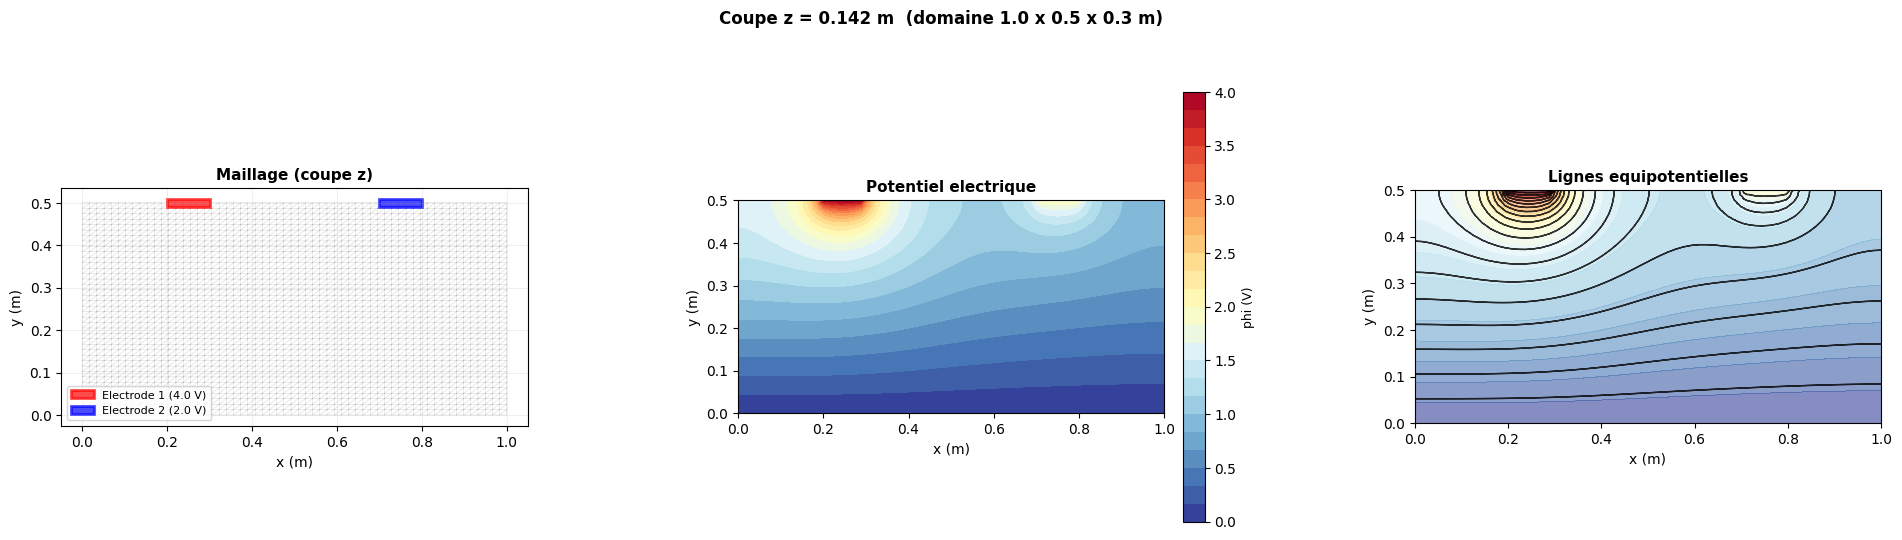

Figure 1 sauvegardee : coplanar_3d_results.png


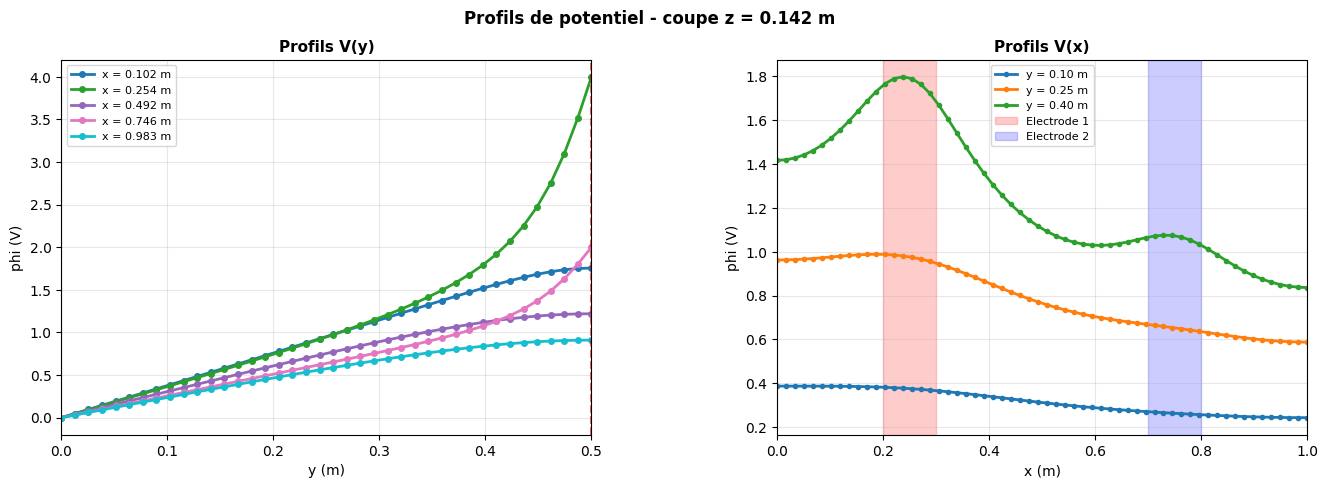

Figure 2 sauvegardee : coplanar_3d_profiles.png


In [4]:
fem = CoplanarElectrodesFEM(
    use_electrode2 = USE_ELECTRODE2,
    length         = LENGTH,
    height         = HEIGHT,
    depth          = DEPTH,
    nx             = NX,
    ny             = NY,
    nz             = NZ,
    electrode1_pos = ELECTRODE1_POS,
    electrode2_pos = ELECTRODE2_POS,
    epsilon_r      = EPSILON_R,
)

phi = fem.solve(V_ELECTRODE1, V_ELECTRODE2, V_BOTTOM)
E   = fem.compute_electric_field()
fem.plot_results(V_ELECTRODE1, V_ELECTRODE2, V_BOTTOM,
                 x_cuts=X_CUTS,
                 z_cut=Z_CUT)


## 5. Profil du potentiel selon z

  x=0.49 m, y=0.50 m : V in [1.2064, 1.2193] V  (Delta = 0.0129 V)
  x=0.25 m, y=0.37 m : V in [1.4787, 1.5824] V  (Delta = 0.1036 V)
  x=0.20 m, y=0.10 m : V in [0.3811, 0.3813] V  (Delta = 0.0002 V)
  x=0.25 m, y=0.47 m : V in [1.8913, 3.0990] V  (Delta = 1.2077 V)


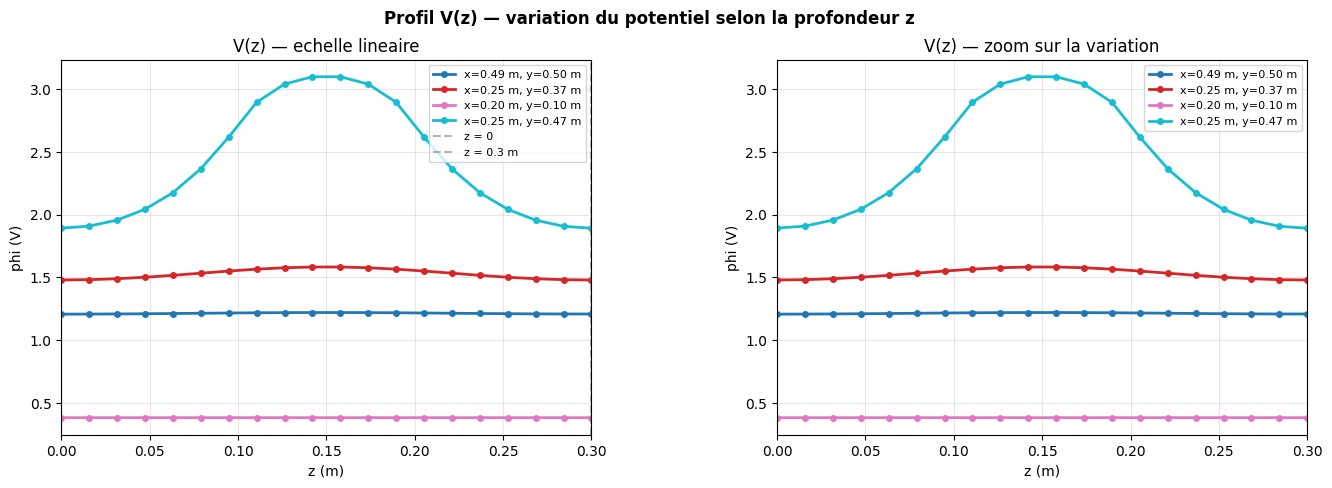

Figure sauvegardee : coplanar_3d_profile_z.png

Interpretation : si V(z) est quasi-constant, le champ est
essentiellement 2D dans le plan (x,y) — la geometrie est
suffisamment large en z. Une variation notable indique un
effet de bord en profondeur.


In [5]:
# ── Profil V(z) : potentiel selon la profondeur z ──────────────────────────
# Differents points (x, y) sont sonderondes le long de z pour observer
# si le potentiel varie selon la troisieme dimension.
#
# Points par defaut :
#   - proche electrode, en haut
#   - centre du domaine
#   - pres du fond
#
# Vous pouvez personnaliser les points (x, y) a sonder :
XY_POINTS = [
    (LENGTH * 0.5,  HEIGHT * 1),   
    (LENGTH * 0.25,  HEIGHT * 0.75),   
    (LENGTH * 0.2,  HEIGHT * 0.2),   
    (ELECTRODE1_POS[0] + (ELECTRODE1_POS[1]-ELECTRODE1_POS[0])/2, HEIGHT * 0.95),  # milieu electrode
]

fem.plot_profile_z(xy_points=XY_POINTS)


## 6. Sauvegarde des données

In [6]:
np.savez(
    'coplanar_data.npz',
    nodes            = fem.nodes,
    elements         = fem.elements,
    phi              = phi,
    E_field          = E,
    electrode1_nodes = fem.electrode1_nodes,
    electrode2_nodes = fem.electrode2_nodes,
    parameters       = {
        'length'         : LENGTH,
        'height'         : HEIGHT,
        'depth'          : DEPTH,
        'electrode1_pos' : ELECTRODE1_POS,
        'electrode2_pos' : ELECTRODE2_POS,
        'epsilon_r'      : EPSILON_R,
        'V_electrode1'   : V_ELECTRODE1,
        'V_electrode2'   : V_ELECTRODE2,
        'V_bottom'       : V_BOTTOM,
    },
)
print("Donnees sauvegardees : coplanar_data.npz")

Donnees sauvegardees : coplanar_data.npz
